# Lab | Tableau — Python equivalent

The graded deliverable for this lab is the Tableau workbook
([`tableau-lab.twbx`](tableau-lab.twbx)). This notebook rebuilds the same
four views in pandas/seaborn, so the numbers behind each Tableau sheet are
reproducible and checkable from the repo.

**Dataset:** `we_fn_use_c_marketing_customer_value_analysis.csv` — auto-insurance
customers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

df = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/we_fn_use_c_marketing_customer_value_analysis.csv")
df.shape

(9134, 24)

## 1. Data import & the measures/dimensions question

Step 4 of the lab is reviewing what Tableau auto-assigned as a measure vs. a dimension. The pandas equivalent is looking at the dtypes and asking which numeric columns are actually *counts or labels* rather than things worth summing.

In [2]:
df.dtypes.to_frame("dtype").assign(
    n_unique=df.nunique(),
    sample=[df[c].dropna().iloc[0] for c in df.columns],
)

,dtype,n_unique,sample
Customer,str,9134,BU79786
State,str,5,Washington
Customer Lifetime Value,float64,8041,2763.519279
Response,str,2,No
Coverage,str,3,Basic
Education,str,5,Bachelor
Effective To Date,str,59,2/24/11
EmploymentStatus,str,5,Employed
Gender,str,2,F
Income,int64,5694,56274


Numeric but **not** really measures — these are the ones to fix in Tableau:

- `Customer` — an ID (it's a string here, but the principle holds).
- `Number of Policies`, `Number of Open Complaints` — small-integer counts.
- `Months Since Last Claim`, `Months Since Policy Inception` — ordinal, not additive.

Genuine measures: `Customer Lifetime Value`, `Income`, `Monthly Premium Auto`,
`Total Claim Amount`.

## 2 & 5. Customers by Gender

Gender
F    4658
M    4476
Name: count, dtype: int64

share:
 Gender
F    51.0
M    49.0
Name: count, dtype: float64


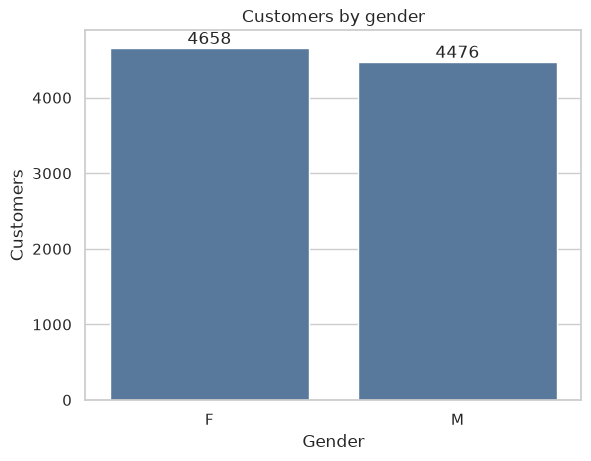

In [3]:
gender = df["Gender"].value_counts()
print(gender)
print("\nshare:\n", (gender / len(df) * 100).round(1))

ax = sns.countplot(data=df, x="Gender", order=gender.index, color="#4C78A8")
ax.set(title="Customers by gender", xlabel="Gender", ylabel="Customers")
ax.bar_label(ax.containers[0])
plt.show()

Almost an even split (51/49). In Tableau this is a **count of rows**, so if the bars look wildly different the pill is being summed, not counted.

## 3 & 6. Customers by EmploymentStatus, segmented by Gender

Gender               F     M
EmploymentStatus            
Employed          2937  2761
Unemployed        1135  1182
Medical Leave      214   218
Disabled           244   161
Retired            128   154


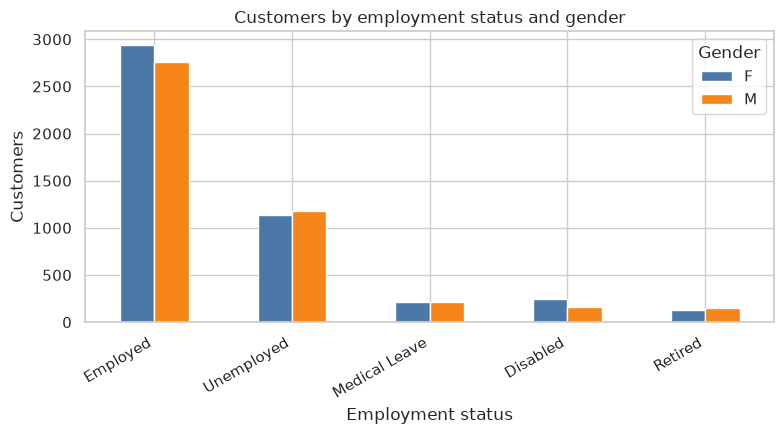

In [4]:
emp = df.groupby(["EmploymentStatus", "Gender"]).size().unstack()
emp = emp.loc[emp.sum(axis=1).sort_values(ascending=False).index]
print(emp)

ax = emp.plot(kind="bar", figsize=(8, 4.5), color=["#4C78A8", "#F58518"])
ax.set(title="Customers by employment status and gender",
       xlabel="Employment status", ylabel="Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

Employed + Unemployed is ~88% of the base, so the three small categories (Medical Leave, Retired, Disabled) disappear unless the bars are sorted descending.

## 7. Customers by State — treemap

In [5]:
state = df["State"].value_counts()
print(state)
print("\nCalifornia + Oregon share:", round(state.head(2).sum() / len(df) * 100, 1), "%")

State
California    3150
Oregon        2601
Arizona       1703
Nevada         882
Washington     798
Name: count, dtype: int64

California + Oregon share: 63.0 %


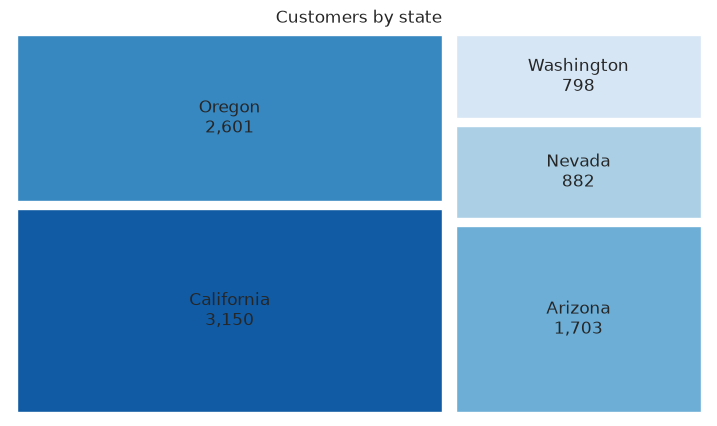

In [6]:
try:
    import squarify
    plt.figure(figsize=(9, 5))
    squarify.plot(sizes=state.values,
                  label=[f"{s}\n{n:,}" for s, n in state.items()],
                  color=sns.color_palette("Blues_r", len(state)), pad=True)
    plt.axis("off")
    plt.title("Customers by state")
except ImportError:
    ax = state.plot(kind="barh", color="#4C78A8", figsize=(7, 3.5))
    ax.set(title="Customers by state (treemap stand-in)", xlabel="Customers")
    ax.invert_yaxis()
plt.show()

Only five states, all West Coast / Southwest — the treemap is really a five-tile view.

## 8. Marital Status x Gender — cross table

Gender,F,M
Marital Status,,
Married,2779,2519
Single,1170,1297
Divorced,709,660


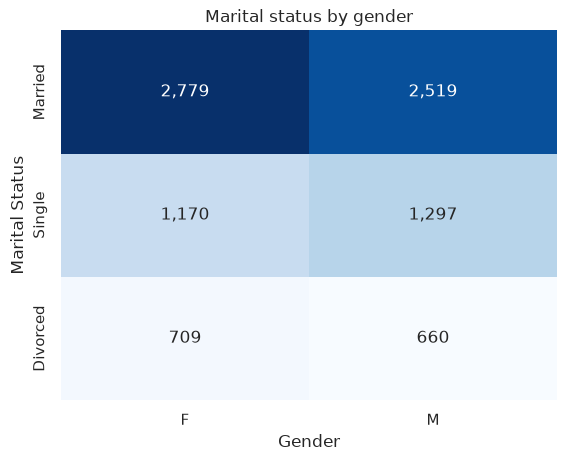

In [7]:
ct = pd.crosstab(df["Marital Status"], df["Gender"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
display(ct)

ax = sns.heatmap(ct, annot=True, fmt=",d", cmap="Blues", cbar=False)
ax.set(title="Marital status by gender")
plt.show()

Married dominates for both genders. The one asymmetry: **Single** is the
only row where men outnumber women (1,297 vs. 1,170) — every other row runs the
other way, which matches the overall 51/49 female skew.

## 9 & 10. Dashboard and save

These two steps have no pandas equivalent — assembling the sheets into an
interactive dashboard and saving `tableau-lab.twbx` happens in Tableau. The
workbook in this folder has the four sheets above plus a `Customer Overview`
dashboard.